## What is Prostate Cancer?
Prostate cancer is cancer that occurs in the prostate ,a small walnut-shaped gland in men that produces the seminal fluid that nourishes and transports sperm.

Prostate cancer is one of the most common types of cancer in men. Usually prostate cancer grows slowly and is initially confined to the prostate gland, where it may not cause serious harm. However, while some types of prostate cancer grow slowly and may need minimal or even no treatment, other types are aggressive and can spread quickly.

<img src="https://www.mayoclinic.org/-/media/kcms/gbs/patient-consumer/images/2013/11/15/17/38/ds00043_-my01633_im01561_prostca1thu_jpg.jpg" height="100px">



# Prostate Cancer AI for Clinical Decision Support project

# Preliminaries
Now Let's Begin by Importing the data

In [ ]:
# === SETUP & CONFIGURATION ===
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import openslide
import cv2
import warnings

warnings.filterwarnings('ignore')

# Fix style for Kaggle environment
plt.style.use('seaborn')        # Safe style for older matplotlib
sns.set_style("whitegrid")
sns.set_palette("husl")

%matplotlib inline

# Paths
BASE_PATH = Path("/kaggle/input/prostate-cancer-grade-assessment")
TRAIN_IMG_DIR = BASE_PATH / "train_images"
TRAIN_MASK_DIR = BASE_PATH / "train_label_masks"

# Load data
train = pd.read_csv(BASE_PATH / "train.csv")
print(f"Train shape: {train.shape}")
print(f"Available styles: {plt.style.available[:10]}...")  # For debugging

Train shape: (10616, 4)
Available styles: ['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn']...


## Domain Knowledge

Prostate cancer grading uses the **ISUP Grade Group** (0-5) derived from Gleason patterns.
- Grade 0: No cancer
- Grades 1-5: Increasing aggressiveness

In [ ]:
BASE_FOLDER = "/kaggle/input/prostate-cancer-grade-assessment/"
!ls {BASE_FOLDER}

sample_submission.csv  test.csv  train.csv  train_images  train_label_masks


In [ ]:
mask_dir = f'{BASE_FOLDER}/train_label_masks'

In [ ]:
train = pd.read_csv(BASE_FOLDER+"train.csv")
test = pd.read_csv(BASE_FOLDER+"test.csv")
sub = pd.read_csv(BASE_FOLDER+"sample_submission.csv")

In [ ]:
train.head()

,image_id,data_provider,isup_grade,gleason_score
0,0005f7aaab2800f6170c399693a96917,karolinska,0,0+0
1,000920ad0b612851f8e01bcc880d9b3d,karolinska,0,0+0
2,0018ae58b01bdadc8e347995b69f99aa,radboud,4,4+4
3,001c62abd11fa4b57bf7a6c603a11bb9,karolinska,4,4+4
4,001d865e65ef5d2579c190a0e0350d8f,karolinska,0,0+0


**Now that we know everything about ISUP_grade and Gleason_score , let's look at how many unique values they have got, as per our guesses,ISUP must have 6 unique values (1-5 grades and 0 for non cancer) and Gleason_score should have 8 values in total (2-10 for scores))**

In [ ]:
print("unique ids : ", len(train.image_id.unique()))
print("unique data provider : ", len(train.data_provider.unique()))
print("unique isup_grade(target) : ", len(train.isup_grade.unique()))
print("unique gleason_score : ", len(train.gleason_score.unique()))

unique ids :  10616
unique data provider :  2
unique isup_grade(target) :  6
unique gleason_score :  11


**Interesting Right? We were right about ISUP but gleason score has 11 unique values . Yes you right in thinking , there can be two values for gleason score 7 i.e (3+4 and 4+3) as we had learned in the video these both have different meanings .
Let's Verify if its the case**

In [ ]:
train['gleason_score'].unique()

array(['0+0', '4+4', '3+3', '4+3', 'negative', '4+5', '3+4', '5+4', '5+5',
       '5+3', '3+5'], dtype=object)

**SO we can clearly see that our understanding was correct.However I wonder What the label 'Negative' means when we already have 0+0 for no cancer.
Let's check what is the ISUP grade for these gleason scores**

In [ ]:
print(train[train['gleason_score']=='0+0']['isup_grade'].unique())
print(train[train['gleason_score']=='negative']['isup_grade'].unique())

[0]
[0]


That's Quite Interesting , they both map to zero ISUP grade . I wonder why there are two labels mapping to the same thing,let's also check their number

In [ ]:
print(len(train[train['gleason_score']=='0+0']['isup_grade']))
print(len(train[train['gleason_score']=='negative']['isup_grade']))

1925
967


That's Quite a big number, it's (2892/10616) 27 oercent of the total data

**We have seem from the figure showing mappings of ISUP from gleason that 3+4 and 4+3 map to different ISUP scores while other pairs like 3-5 and 5-3 , 4-5 and 5-4 map to same ISUP , let's verify it**

In [ ]:
print(train[(train['gleason_score']=='3+4') | (train['gleason_score']=='4+3')]['isup_grade'].unique())
print(train[(train['gleason_score']=='3+5') | (train['gleason_score']=='5+3')]['isup_grade'].unique())
print(train[(train['gleason_score']=='5+4') | (train['gleason_score']=='4+5')]['isup_grade'].unique())

[3 2]
[4]
[5]


Hence it is indeed the case<br>
**It is due to this reason, modeling this as a predictive problem for gleason score then converting it into ISUP is a much better strategy than to model it as ISUP predictive problem directly**<br><br>
Let's also check if 3+4 and 4+3 gleason scores maps to 2 and 3  respectively

In [ ]:
print(train[train['gleason_score']=='3+4']['isup_grade'].unique())
print(train[train['gleason_score']=='4+3']['isup_grade'].unique())

[2]
[3 2]


We can see that 3+4 maps to one unique Isup i.e 2 but to our surprise 4+3 maps to two different values , hence we have some mislablled info here, Let's go ahead and check that

In [ ]:
train[(train['isup_grade'] == 2) & (train['gleason_score'] == '4+3')]

,image_id,data_provider,isup_grade,gleason_score
7273,b0a92a74cb53899311acc30b7405e101,karolinska,2,4+3


We can see there is one mislabelled information like that, let's go ahead and drop this

In [ ]:
train.drop([7273],inplace=True)

**Also negative and 0+0 are same labels only from different data-providers and are interchangeable**
<br>Let's go ahead and change negative to '0+0'

In [ ]:
train['gleason_score'] = train['gleason_score'].apply(lambda x: "0+0" if x=="negative" else x)

### LET's now Look at the test file

In [ ]:
print("shape : ", test.shape)
print("unique ids : ", len(test.image_id.unique()))
print("unique data provider : ", len(test.data_provider.unique()))

shape :  (3, 2)
unique ids :  3
unique data provider :  2


They are only 3 images in the test and they too are hidden and we have access to them only when we are submitting , for information on how to submit on hidden test set, read here : https://www.kaggle.com/c/prostate-cancer-grade-assessment/discussion/145219

# EDA


# BASIC EDA

In [ ]:
# ISUP Grade Distribution
grade_dist = train['isup_grade'].value_counts().sort_index().reset_index()
grade_dist.columns = ['ISUP_Grade', 'Count']
grade_dist['Percentage'] = (grade_dist['Count'] / len(train) * 100).round(2)

# Styled Table
grade_dist.style.background_gradient(cmap='Purples', subset=['Count'])\
    .format({'Percentage': '{:.1f}%'})\
    .set_caption("ISUP Grade Distribution")

,ISUP_Grade,Count,Percentage
0,0,2892,27.2%
1,1,2666,25.1%
2,2,1342,12.6%
3,3,1242,11.7%
4,4,1249,11.8%
5,5,1224,11.5%


In [ ]:
# ISUP Grade Distribution - Clean & Beautiful
grade_dist = (
    train['isup_grade']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'index': 'ISUP Grade', 'isup_grade': 'Count'})
)

# Add percentage
grade_dist['Percentage'] = (grade_dist['Count'] / grade_dist['Count'].sum() * 100).round(2)

# Display with styling
styled = grade_dist.style\
    .background_gradient(cmap='Purples', subset=['Count'])\
    .format({'Percentage': '{:.2f}%'})\
    .set_caption("ISUP Grade Distribution in Training Set")\
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])

styled

,ISUP Grade,Count,Percentage
0,0,2892,27.24%
1,1,2666,25.12%
2,2,1342,12.64%
3,3,1242,11.70%
4,4,1249,11.77%
5,5,1224,11.53%


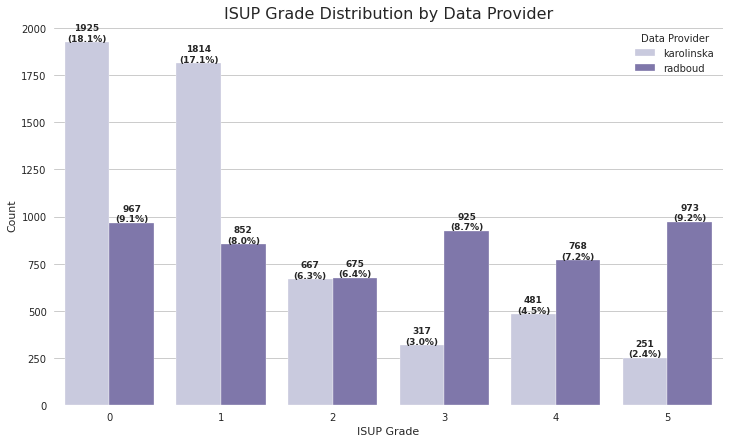

In [ ]:
# Distribution by Data Provider
plt.figure(figsize=(12, 7))
ax = sns.countplot(x="isup_grade", hue="data_provider", data=train, palette="Purples")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 8,
            f'{count}\n({percentage:.1f}%)', ha="center", fontsize=9, fontweight='bold')

plt.title("ISUP Grade Distribution by Data Provider", fontsize=16)
plt.xlabel("ISUP Grade")
plt.ylabel("Count")
plt.legend(title="Data Provider")
plt.show()

We see that the isup_grade 0 and 1 i.e no cancer, has the most number of values and that's what expected in case of most medical datasets , the target class will always be underrepresented and that's also the most important challenge when performing machine learning tasks on Medical DATA

Now let's Look at how much data is provided by which data-provider

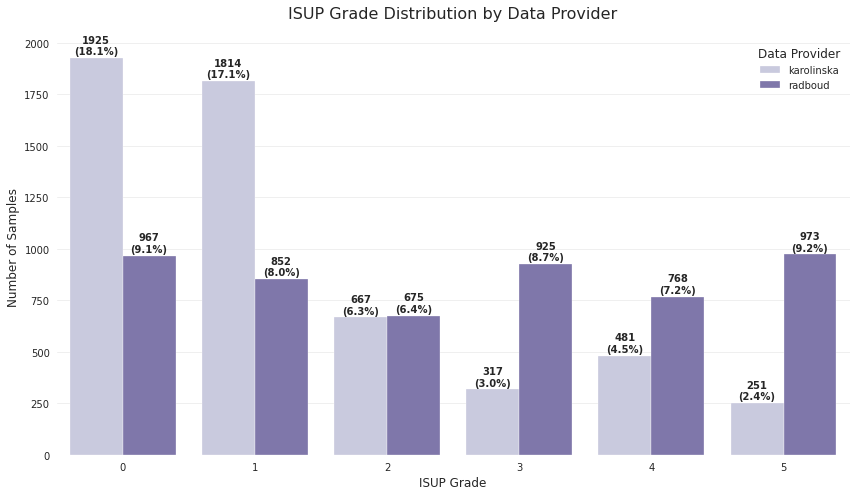

In [ ]:
# ISUP Grade Distribution by Data Provider - Enhanced
plt.figure(figsize=(12, 7))

ax = sns.countplot(
    x="isup_grade",
    hue="data_provider",
    data=train,
    palette="Purples"
)

# Add count + percentage labels on top of each bar
total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.text(
        p.get_x() + p.get_width()/2.,
        p.get_height() + 8,
        f'{count}\n({percentage:.1f}%)',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight='bold'
    )

plt.title("ISUP Grade Distribution by Data Provider", fontsize=16, pad=20)
plt.xlabel("ISUP Grade", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(title="Data Provider", title_fontsize=12)

# Improve layout
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Advanced Image Statistics (Fixed)

In [ ]:
def extract_image_stats(image_id, level=1):
    try:
        slide = openslide.OpenSlide(str(TRAIN_IMG_DIR / f"{image_id}.tiff"))
        width, height = slide.dimensions
        img = np.array(slide.read_region((0,0), level, slide.level_dimensions[level]))[:,:,:3]
        slide.close()

        return {
            'image_id': image_id,
            'mean_brightness': float(np.mean(img)),
            'std_brightness': float(np.std(img)),
            'mean_r': float(np.mean(img[:,:,0])),
            'mean_g': float(np.mean(img[:,:,1])),
            'mean_b': float(np.mean(img[:,:,2])),
            'contrast': float(np.std(img)),
            'aspect_ratio': width / height,
            'width': width,
            'height': height
        }
    except:
        return None

# Sample
sample_ids = train['image_id'].sample(250, random_state=42)
stats_list = [extract_image_stats(i) for i in sample_ids]
stats_df = pd.DataFrame([s for s in stats_list if s is not None])

stats_df = stats_df.merge(train[['image_id','isup_grade','data_provider']], on='image_id')
print(f"Processed {len(stats_df)} images successfully")

Processed 250 images successfully


# Visualizing the GLEASON_SCORE distribution wrt Data_providers


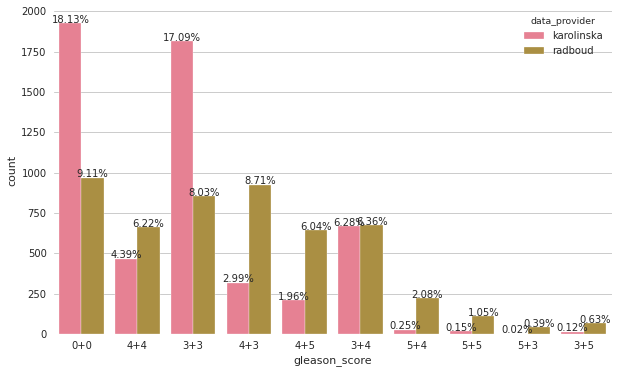

In [ ]:

fig = plt.figure(figsize=(10,6))
ax = sns.countplot(x="gleason_score", hue="data_provider", data=train)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(100*height/10616),
                ha="center")

# Image EDA
Now we can finally move on to Image EDA . BUT since we are complete beginners, let's first+ understand the format of image that is provided to us and all the image related jargons that we will be using further



<br> I will be using openslide to display images as I learned it in this competition from a very informative kernel:
https://www.kaggle.com/wouterbulten/getting-started-with-the-panda-dataset
<br>The benefit of OpenSlide is that we can load arbitrary regions of the slide, without loading the whole image in memory. Want to interactively view a slide? We have added an interactive viewer to this notebook in the last section.

You can read more about the OpenSlide python bindings in the documentation: https://openslide.org/api/python/

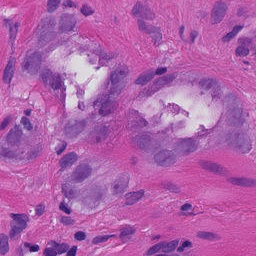

In [ ]:
'''
Example for using Openslide to display an image
'''


# Open the image (does not yet read the image into memory)
example = openslide.OpenSlide(os.path.join(BASE_FOLDER+"train_images", '005e66f06bce9c2e49142536caf2f6ee.tiff'))

# Read a specific region of the image starting at upper left coordinate (x=17800, y=19500) on level 0 and extracting a 256*256 pixel patch.
# At this point image data is read from the file and loaded into memory.
patch = example.read_region((17800,19500), 0, (256, 256))

# Display the image
display(patch)

# Close the opened slide after use
example.close()

Now Let's see what all information can we get out of an image after creating an Openslide object

In [ ]:
train = train.set_index('image_id')
train.head()

,data_provider,isup_grade,gleason_score
image_id,,,
0005f7aaab2800f6170c399693a96917,karolinska,0,0+0
000920ad0b612851f8e01bcc880d9b3d,karolinska,0,0+0
0018ae58b01bdadc8e347995b69f99aa,radboud,4,4+4
001c62abd11fa4b57bf7a6c603a11bb9,karolinska,4,4+4
001d865e65ef5d2579c190a0e0350d8f,karolinska,0,0+0


In [ ]:
def get_values(image,max_size=(600,400)):
    slide = openslide.OpenSlide(os.path.join(BASE_FOLDER+"train_images", f'{image}.tiff'))

    # Here we compute the "pixel spacing": the physical size of a pixel in the image.
    # OpenSlide gives the resolution in centimeters so we convert this to microns.
    f,ax =  plt.subplots(2 ,figsize=(6,16))
    spacing = 1 / (float(slide.properties['tiff.XResolution']) / 10000)
    patch = slide.read_region((1780,1950), 0, (256, 256)) #ZOOMED FUGURE
    ax[0].imshow(patch)
    ax[0].set_title('Zoomed Image')


    ax[1].imshow(slide.get_thumbnail(size=max_size)) #UNZOOMED FIGURE
    ax[1].set_title('Full Image')


    print(f"File id: {slide}")
    print(f"Dimensions: {slide.dimensions}")
    print(f"Microns per pixel / pixel spacing: {spacing:.3f}")
    print(f"Number of levels in the image: {slide.level_count}")
    print(f"Downsample factor per level: {slide.level_downsamples}")
    print(f"Dimensions of levels: {slide.level_dimensions}\n\n")

    print(f"ISUP grade: {train.loc[image, 'isup_grade']}")
    print(f"Gleason score: {train.loc[image, 'gleason_score']}")

* This Function prints Zoomed and Non-Zoomed images side by side and also all the information that can be derived from it
* You can read about what every function does in the documentation of Open slide
* You can play around with the read_region to zoom in different parts of an image and by little modifications you can build a function that takes in multiple images and displays their zoomed and non-Zoomed Images side by side

File id: OpenSlide('/kaggle/input/prostate-cancer-grade-assessment/train_images/07a7ef0ba3bb0d6564a73f4f3e1c2293.tiff')
Dimensions: (24900, 29228)
Microns per pixel / pixel spacing: 0.503
Number of levels in the image: 3
Downsample factor per level: (1.0, 4.0, 16.00457121779945)
Dimensions of levels: ((24900, 29228), (6225, 7307), (1556, 1826))


ISUP grade: 4
Gleason score: 4+4


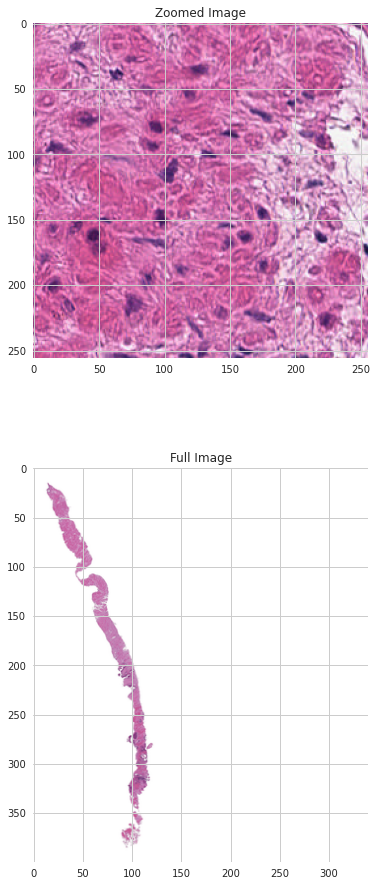

In [ ]:
get_values('07a7ef0ba3bb0d6564a73f4f3e1c2293')

### Now Let's Look at the Zoomed Images having different ISUP and gleason_score

Looking at the images we can see and try to apply what we learned in the video for giving gleason_score

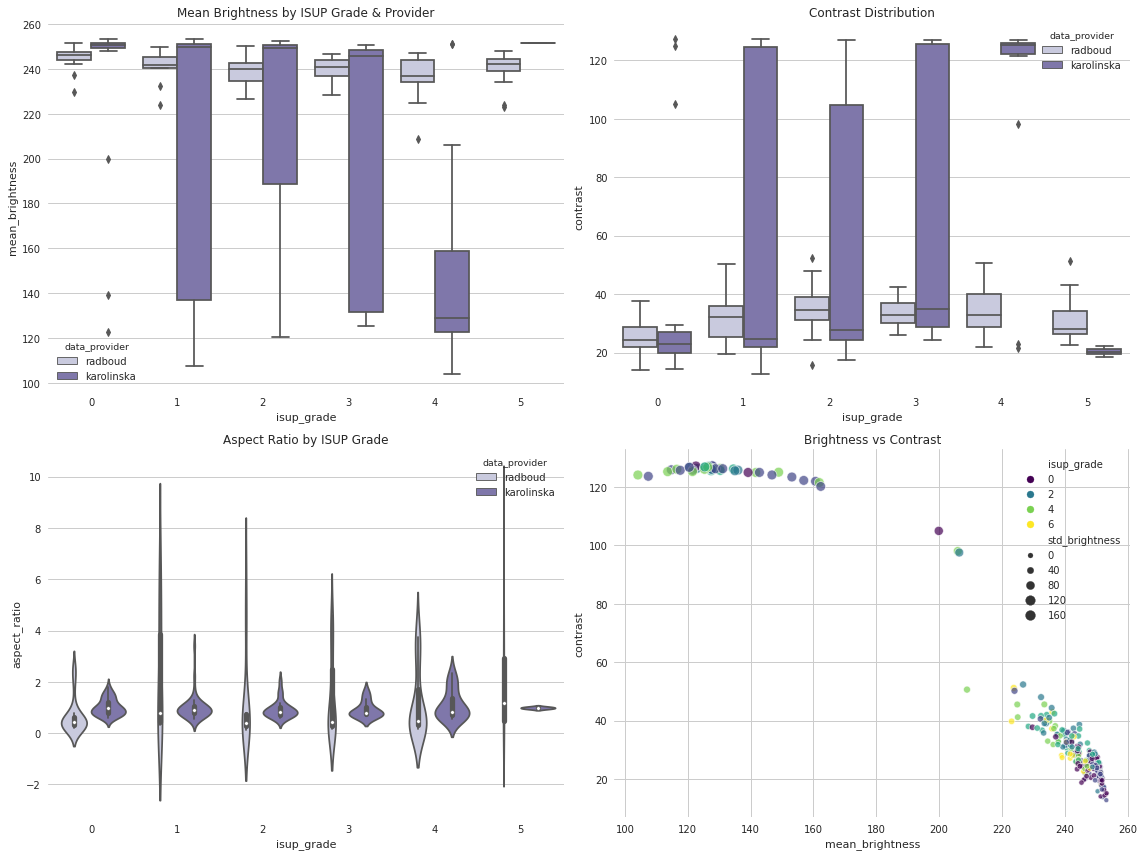

In [ ]:
# Better Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Brightness by ISUP Grade
sns.boxplot(data=stats_df, x='isup_grade', y='mean_brightness',
            hue='data_provider', palette='Purples', ax=axes[0,0])
axes[0,0].set_title("Mean Brightness by ISUP Grade & Provider")

# Contrast
sns.boxplot(data=stats_df, x='isup_grade', y='contrast',
            hue='data_provider', palette='Purples', ax=axes[0,1])
axes[0,1].set_title("Contrast Distribution")

# Aspect Ratio
sns.violinplot(data=stats_df, x='isup_grade', y='aspect_ratio',
               hue='data_provider', palette='Purples', ax=axes[1,0])
axes[1,0].set_title("Aspect Ratio by ISUP Grade")

# Brightness vs Contrast
sns.scatterplot(data=stats_df, x='mean_brightness', y='contrast',
                hue='isup_grade', size='std_brightness',
                palette='viridis', alpha=0.7, ax=axes[1,1])
axes[1,1].set_title("Brightness vs Contrast")

plt.tight_layout()
plt.show()

# Mask Analysis - Cancer Coverage

In [ ]:
def display_images(images):
    '''
    This function takes in input a list of images. It then iterates through the image making openslide objects , on which different functions
    for getting out information can be called later
    '''
    f, ax = plt.subplots(5,3, figsize=(18,22))
    for i, image in enumerate(images):
        slide = openslide.OpenSlide(os.path.join(BASE_FOLDER+"train_images", f'{image}.tiff')) # Making Openslide Object
        #Here we compute the "pixel spacing": the physical size of a pixel in the image,
        #OpenSlide gives the resolution in centimeters so we convert this to microns
        spacing = 1/(float(slide.properties['tiff.XResolution']) / 10000)
        patch = slide.read_region((1780,1950), 0, (256, 256)) #Reading the image as before betweeen x=1780 to y=1950 and of pixel size =256*256
        ax[i//3, i%3].imshow(patch) #Displaying Image
        slide.close()
        ax[i//3, i%3].axis('off')

        image_id = image
        data_provider = train.loc[image, 'data_provider']
        isup_grade = train.loc[image, 'isup_grade']
        gleason_score = train.loc[image, 'gleason_score']
        ax[i//3, i%3].set_title(f"ID: {image_id}\nSource: {data_provider} ISUP: {isup_grade} Gleason: {gleason_score}")

    plt.show()

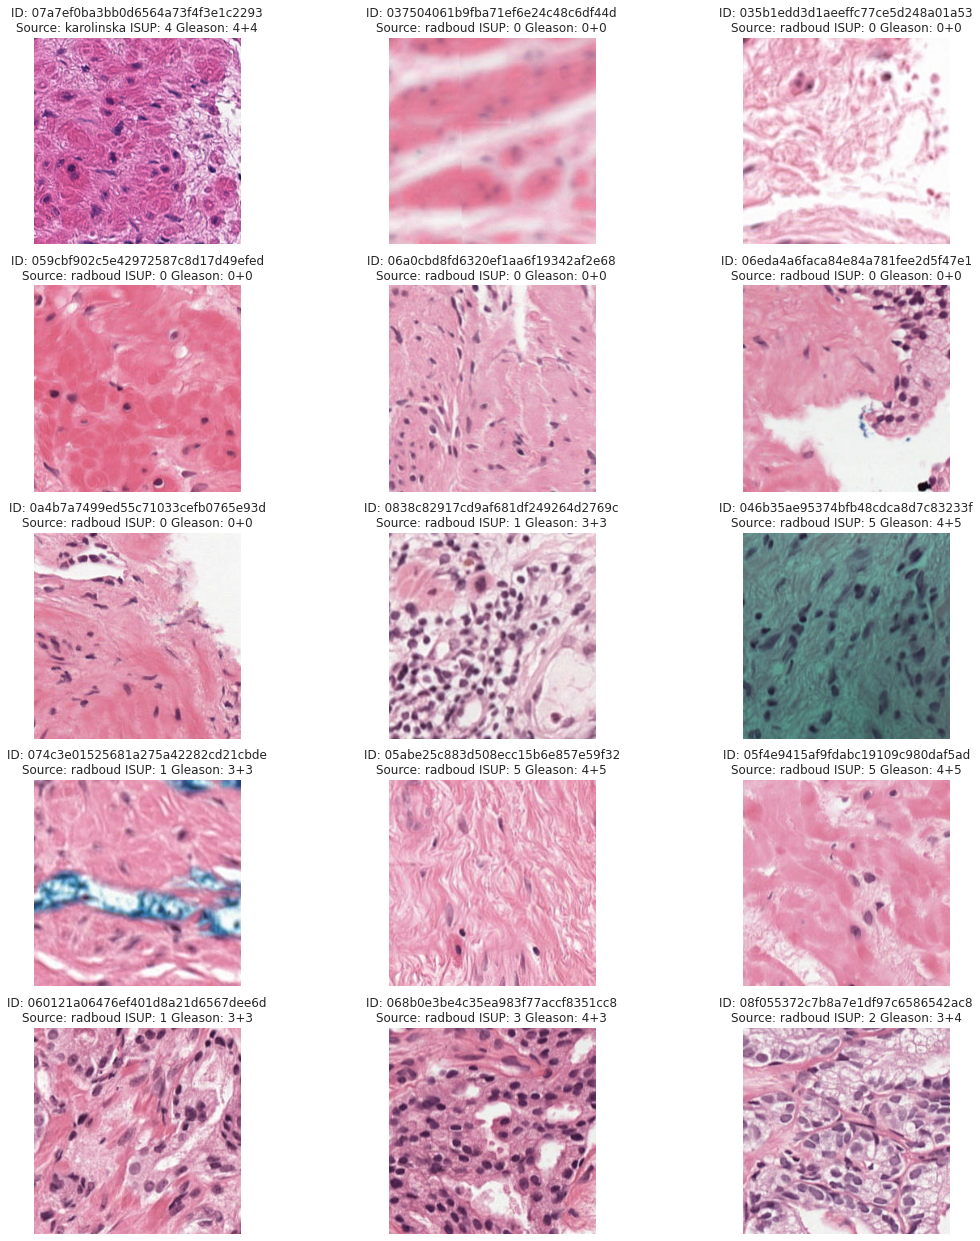

In [ ]:
images = [
'07a7ef0ba3bb0d6564a73f4f3e1c2293',
    '037504061b9fba71ef6e24c48c6df44d',
    '035b1edd3d1aeeffc77ce5d248a01a53',
    '059cbf902c5e42972587c8d17d49efed',
    '06a0cbd8fd6320ef1aa6f19342af2e68',
    '06eda4a6faca84e84a781fee2d5f47e1',
    '0a4b7a7499ed55c71033cefb0765e93d',
    '0838c82917cd9af681df249264d2769c',
    '046b35ae95374bfb48cdca8d7c83233f',
    '074c3e01525681a275a42282cd21cbde',
    '05abe25c883d508ecc15b6e857e59f32',
    '05f4e9415af9fdabc19109c980daf5ad',
    '060121a06476ef401d8a21d6567dee6d',
    '068b0e3be4c35ea983f77accf8351cc8',
    '08f055372c7b8a7e1df97c6586542ac8'
]

display_images(images)

OBSERVATIONS:

* The image dimensions are quite large (typically between 5.000 and 40.000 pixels in both x and y).
* Each slide has 3 levels you can load, corresponding to a downsampling of 1, 4 and 16. Intermediate levels can be created by downsampling a higher resolution level.
* The dimensions of each level differ based on the dimensions of the original image.
* Biopsies can be in different rotations. This rotation has no clinical value, and is only dependent on how the biopsy was collected in the lab.
* There are noticable color differences between the biopsies, this is very common within pathology and is caused by different laboratory procedures.

In [ ]:
import matplotlib
def display_masks(slides):
    f, ax = plt.subplots(2,3, figsize=(18,22))
    for i, slide in enumerate(slides):

        mask = openslide.OpenSlide(os.path.join(mask_dir, f'{slide}_mask.tiff'))
        mask_data = mask.read_region((0,0), mask.level_count - 1, mask.level_dimensions[-1])
        cmap = matplotlib.colors.ListedColormap(['black', 'gray', 'green', 'yellow', 'orange', 'red'])

        ax[i//3, i%3].imshow(np.asarray(mask_data)[:,:,0], cmap=cmap, interpolation='nearest', vmin=0, vmax=5)
        mask.close()
        ax[i//3, i%3].axis('off')

        image_id = slide
        data_provider = train.loc[slide, 'data_provider']
        isup_grade = train.loc[slide, 'isup_grade']
        gleason_score = train.loc[slide, 'gleason_score']
        ax[i//3, i%3].set_title(f"ID: {image_id}\nSource: {data_provider} ISUP: {isup_grade} Gleason: {gleason_score}")
        f.tight_layout()

    plt.show()

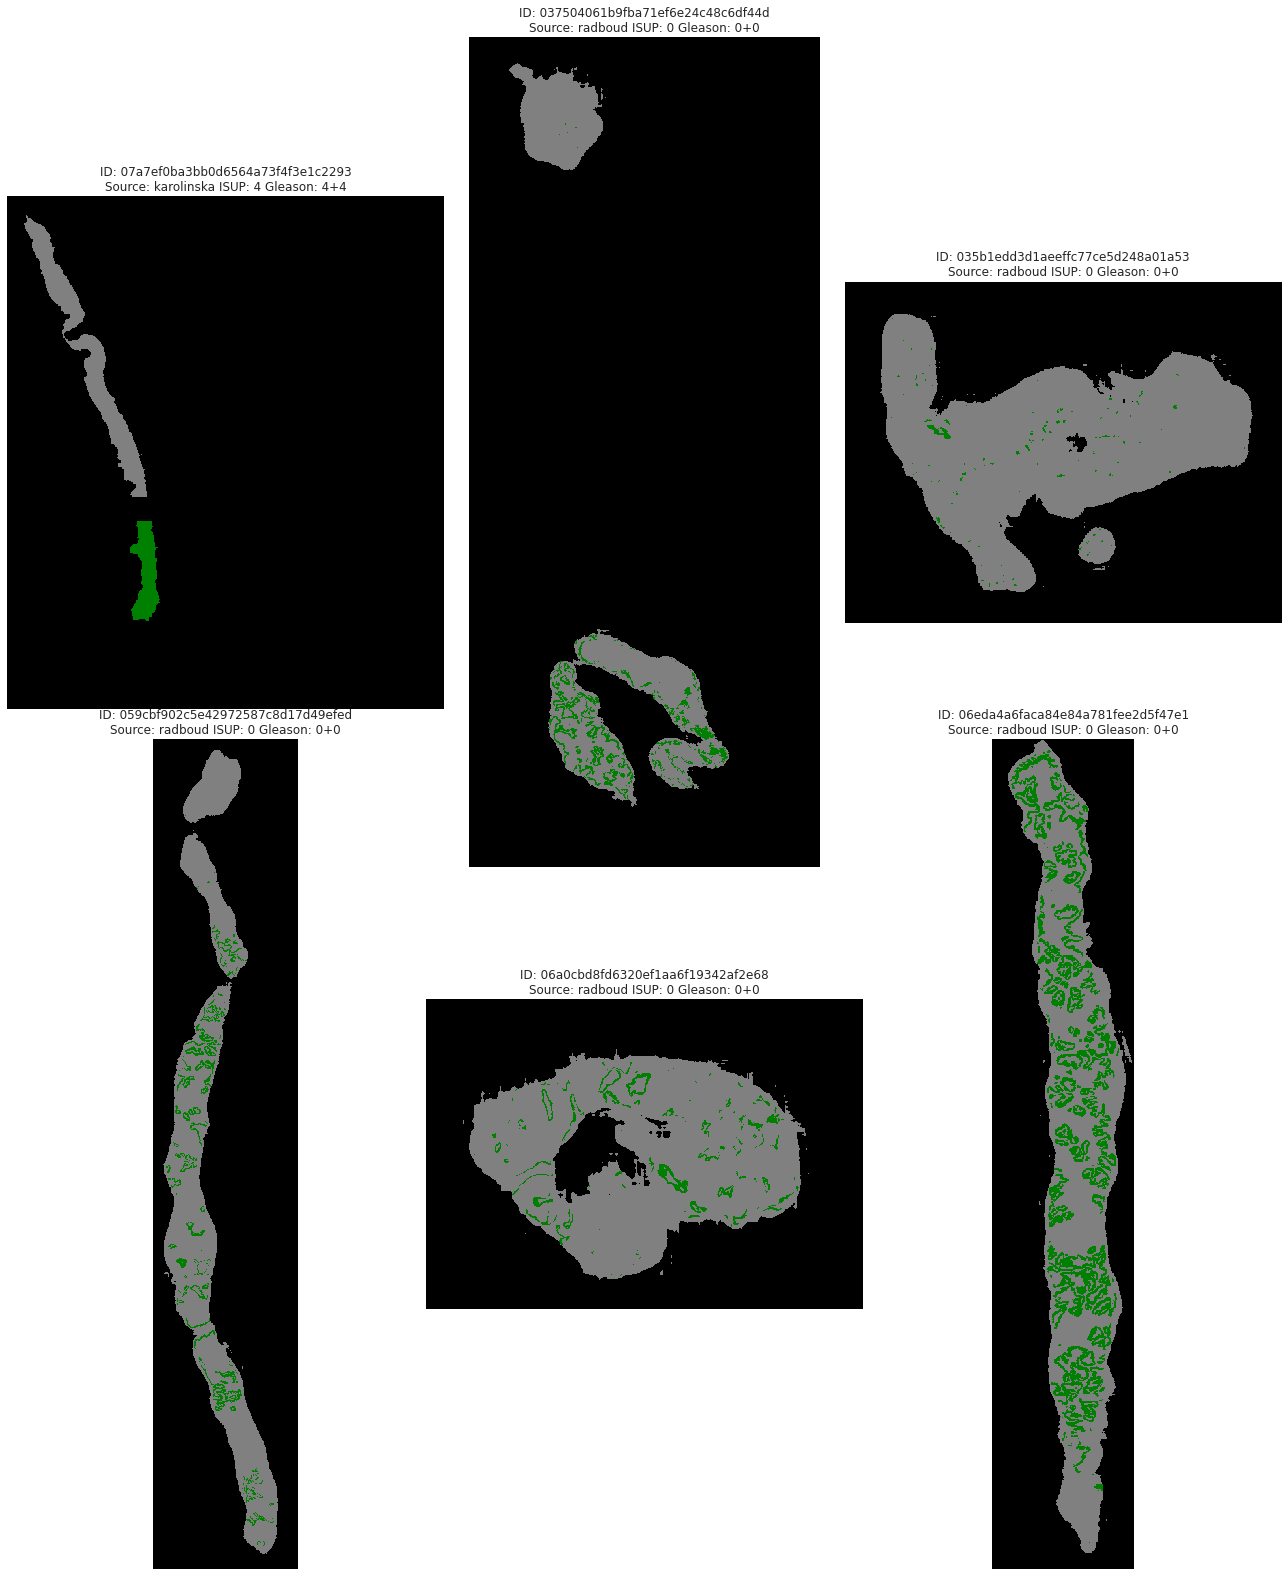

In [ ]:
display_masks(images[:6]) #Visualizing Only six Examples

**Now that we have learned how to visualize masks , let's build a function which prints an image and its mask side by side (provided that there is a mask)**

In [ ]:
def mask_img(image,max_size=(600,400)):
    slide = openslide.OpenSlide(os.path.join(BASE_FOLDER+"train_images", f'{image}.tiff'))
    mask =  openslide.OpenSlide(os.path.join(mask_dir, f'{image}_mask.tiff'))
    # Here we compute the "pixel spacing": the physical size of a pixel in the image.
    # OpenSlide gives the resolution in centimeters so we convert this to microns.
    f,ax =  plt.subplots(1,2 ,figsize=(18,22))
    spacing = 1 / (float(slide.properties['tiff.XResolution']) / 10000)
    img = slide.get_thumbnail(size=(600,400)) #IMAGE

    mask_data = mask.read_region((0,0), mask.level_count - 1, mask.level_dimensions[-1])
    cmap = matplotlib.colors.ListedColormap(['black', 'gray', 'green', 'yellow', 'orange', 'red'])

    ax[0].imshow(img)
    #ax[0].set_title('Image')


    ax[1].imshow(np.asarray(mask_data)[:,:,0], cmap=cmap, interpolation='nearest', vmin=0, vmax=5) #IMAGE MASKS
    #ax[1].set_title('Image_MASK')


    image_id = image
    data_provider = train.loc[image, 'data_provider']
    isup_grade = train.loc[image, 'isup_grade']
    gleason_score = train.loc[image, 'gleason_score']
    ax[0].set_title(f"ID: {image_id}\nSource: {data_provider} ISUP: {isup_grade} Gleason: {gleason_score} IMAGE")
    ax[1].set_title(f"ID: {image_id}\nSource: {data_provider} ISUP: {isup_grade} Gleason: {gleason_score} IMAGE_MASK")

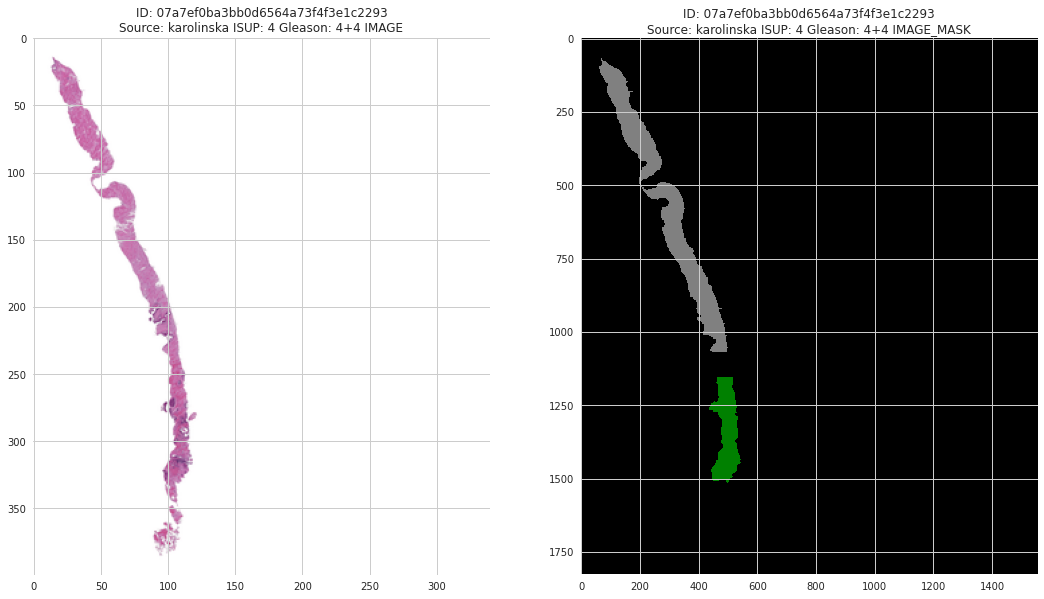

In [ ]:
mask_img('07a7ef0ba3bb0d6564a73f4f3e1c2293')

So we are successful , we can easily use this function to visualize on more than example by doing something like this:

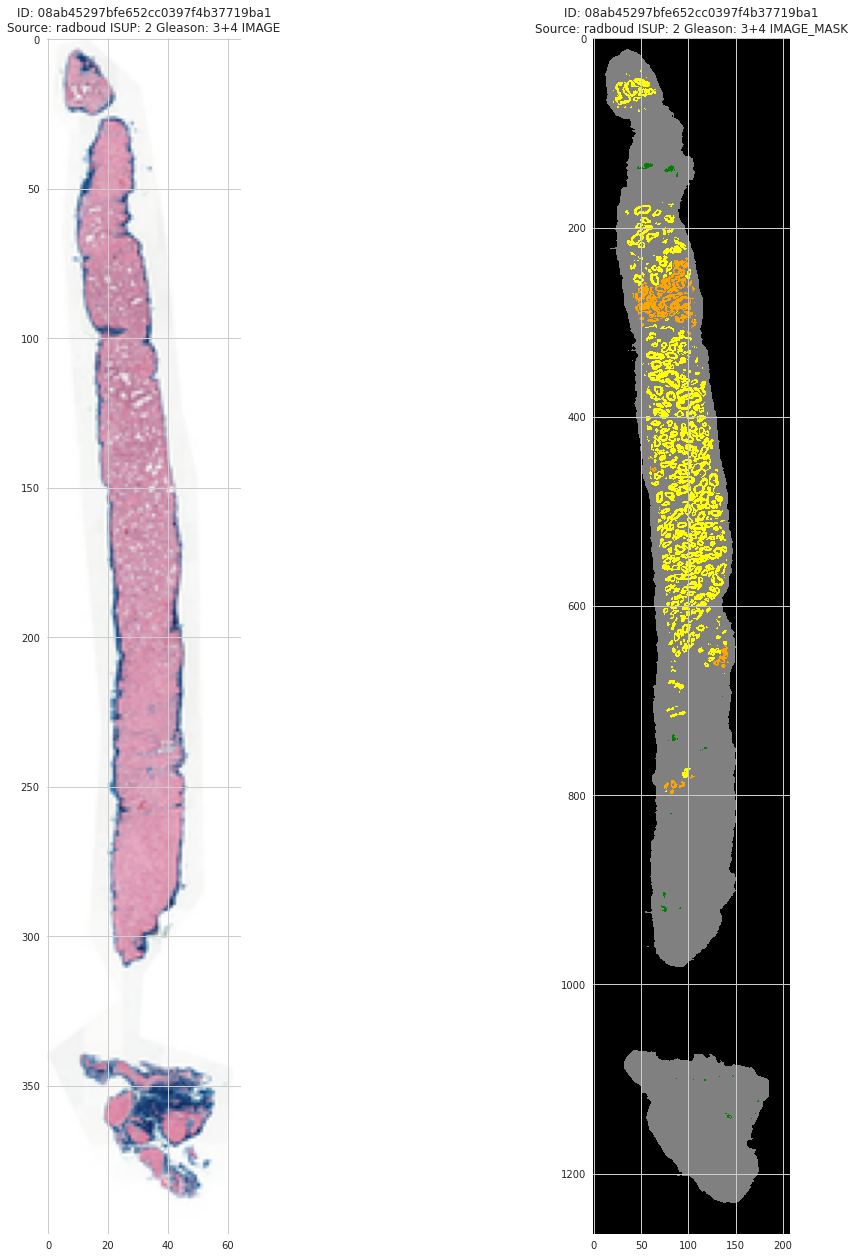

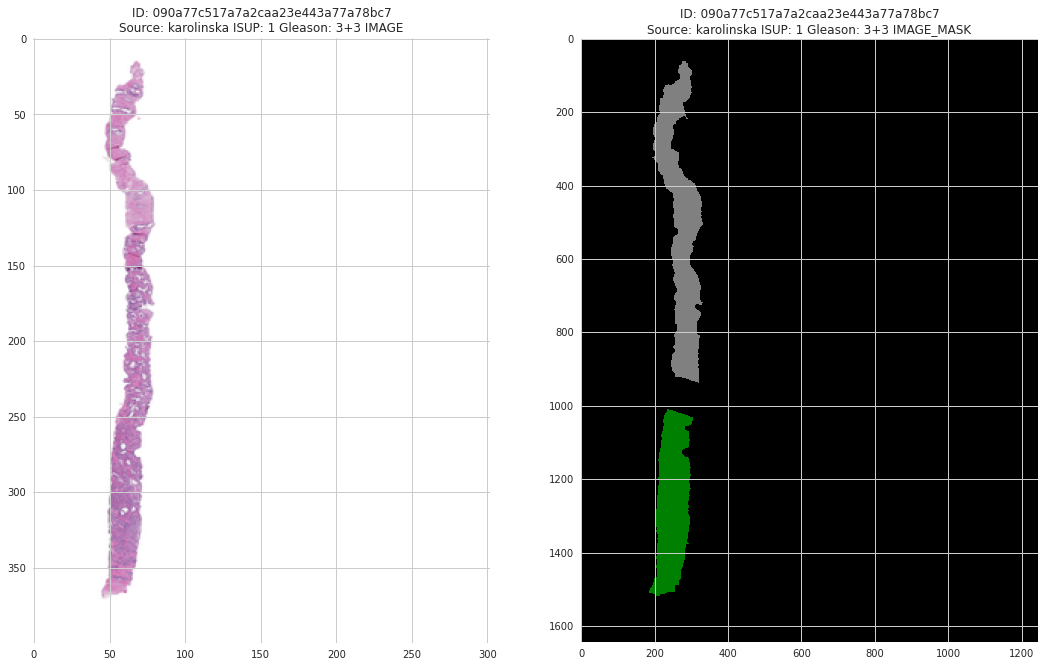

In [ ]:
images1= [
    '08ab45297bfe652cc0397f4b37719ba1',
    '090a77c517a7a2caa23e443a77a78bc7'
]

for image in images1:
    mask_img(image)

Observations:
* The images above shows two example masks from the dataset.The first mask is from Radboudumc and shows two different grades of cancer (shown in yellow and orange). The second mask is from Karolinska, the region that contains cancer is higlighted in green.

* Note that in the second example, eventhough a biopsy contains cancer, not all epithelial tissue has to be cancerous.Thus, Biopsies can contain a mix of cancerous and healthy tissue.

## Differentiating between cancerous and non-cancerous areas using MASKS

Idea Credits: https://www.kaggle.com/akensert/panda-drawing-rectangles-work-in-progress

We will now visualize the cancerous and non-cancerous areas of an image using image_masks and since we know masks are different for different data providers we will have to take into account in the function we built

In [ ]:
def differentiate_cancerous(image_mask):
    mask =  openslide.OpenSlide(os.path.join(mask_dir, f'{image_mask}_mask.tiff'))
    mask_level = mask.read_region((0,0),mask.level_count - 1,mask.level_dimensions[-1]) #Selecting the level
    mask_data = np.asarray(mask_level)[:,:,0] #SELECTING R from RGB

    mask_background = np.where(mask_data == 0, 1, 0).astype(np.uint8) # SELECTING BG
    mask_benign = np.where(mask_data == 1, 1, 0).astype(np.uint8) #SELECTING BENIGN LABELS

    if train.loc[image_mask,'data_provider'] == 'karolinska':
        mask_cancerous = np.where(mask_data == 2, 1, 0).astype(np.uint8) #SELECTING CANCEROUS LABELS
    elif train.loc[image_mask,'data_provider'] == 'radboud':
        mask_cancerous = np.where(mask_data == 5, 1, 0).astype(np.uint8) #SELECTING NON-CANCEROUS LABELS

    return mask_background,mask_benign,mask_cancerous

Now that we have our function let's visualize

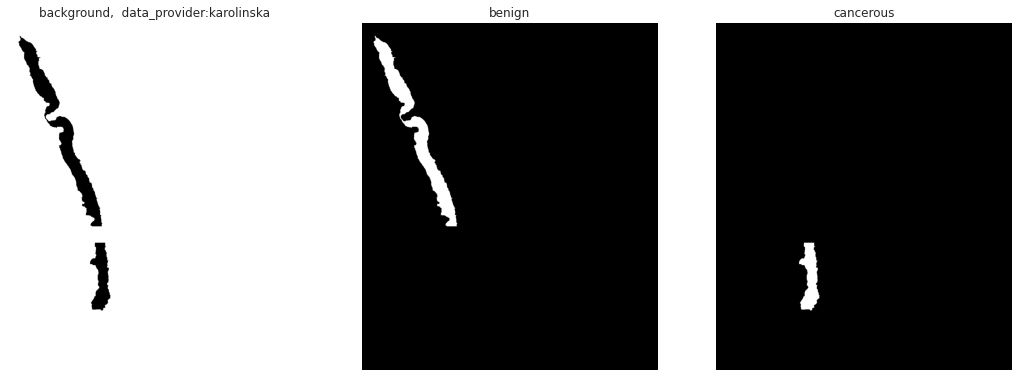

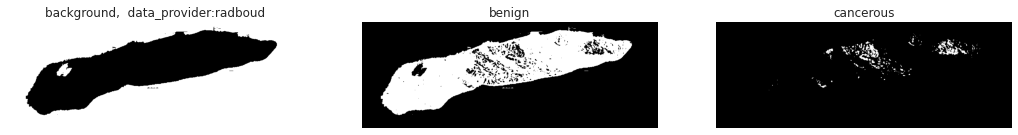

In [ ]:
image2 =[ '07a7ef0ba3bb0d6564a73f4f3e1c2293',
    'ffdc59cd580a1468eac0e6a32dd1ff2d']

for image in image2:
    background,benign,cancerous = differentiate_cancerous(image)

    #if train.loc[image,'data_provider'] == 'karolinska'
    fig, ax = plt.subplots(1, 3, figsize=(18, 12))

    ax[0].imshow(background.astype(float), cmap=plt.cm.gray)
    ax[0].axis('off')
    ax[0].set_title('background,'+'  '+'data_provider:'+train.loc[image]["data_provider"]);
    ax[1].imshow(benign.astype(float), cmap=plt.cm.gray)
    ax[1].axis('off')
    ax[1].set_title('benign');
    ax[2].imshow(cancerous.astype(float), cmap=plt.cm.gray)
    ax[2].axis('off')
    ax[2].set_title('cancerous')

## Overlaying masks on the slides
Now That we have learned how to visualize masks and display them side by side , Let's Overlay them on one another

As the masks have the same dimension as the slides, we can overlay the masks on the tissue to directly see which areas are cancerous. This overlay can help you identifying the different growth patterns. To do this, we load both the mask and the biopsy and merge them using PIL.

In [ ]:
def overlay_mask_on_slide(images, center='radboud', alpha=0.8, max_size=(800, 800)):
    """Show a mask overlayed on a slide."""
    f, ax = plt.subplots(2,3, figsize=(18,22))


    for i, image_id in enumerate(images):
        slide = openslide.OpenSlide(os.path.join(BASE_FOLDER+"train_images", f'{image_id}.tiff'))
        mask = openslide.OpenSlide(os.path.join(mask_dir, f'{image_id}_mask.tiff'))
        slide_data = slide.read_region((0,0), slide.level_count - 1, slide.level_dimensions[-1])
        mask_data = mask.read_region((0,0), mask.level_count - 1, mask.level_dimensions[-1])
        mask_data = mask_data.split()[0]

        # Create alpha mask
        alpha_int = int(round(255*alpha))
        if center == 'radboud':
            alpha_content = np.less(mask_data.split()[0], 2).astype('uint8') * alpha_int + (255 - alpha_int)
        elif center == 'karolinska':
            alpha_content = np.less(mask_data.split()[0], 1).astype('uint8') * alpha_int + (255 - alpha_int)

        alpha_content = PIL.Image.fromarray(alpha_content)
        preview_palette = np.zeros(shape=768, dtype=int)

        if center == 'radboud':
            # Mapping: {0: background, 1: stroma, 2: benign epithelium, 3: Gleason 3, 4: Gleason 4, 5: Gleason 5}
            preview_palette[0:18] = (np.array([0, 0, 0, 0.5, 0.5, 0.5, 0, 1, 0, 1, 1, 0.7, 1, 0.5, 0, 1, 0, 0]) * 255).astype(int)
        elif center == 'karolinska':
            # Mapping: {0: background, 1: benign, 2: cancer}
            preview_palette[0:9] = (np.array([0, 0, 0, 0, 1, 0, 1, 0, 0]) * 255).astype(int)

        mask_data.putpalette(data=preview_palette.tolist())
        mask_rgb = mask_data.convert(mode='RGB')
        overlayed_image = PIL.Image.composite(image1=slide_data, image2=mask_rgb, mask=alpha_content)
        overlayed_image.thumbnail(size=max_size, resample=0)


        ax[i//3, i%3].imshow(overlayed_image)
        slide.close()
        mask.close()
        ax[i//3, i%3].axis('off')

        data_provider = train.loc[image_id, 'data_provider']
        isup_grade = train.loc[image_id, 'isup_grade']
        gleason_score = train.loc[image_id, 'gleason_score']
        ax[i//3, i%3].set_title(f"ID: {image_id}\nSource: {data_provider} ISUP: {isup_grade} Gleason: {gleason_score}")

We will look at only 6 examples for better visuals

Lastly I will add heights and widths of images to my dataframe as it will help with my baseline

In [ ]:
dims, spacings, level_counts = [], [], []
down_levels, level_dims = [], []

for i in train.reset_index().image_id:
    slide = openslide.OpenSlide(BASE_FOLDER+"train_images/"+i+".tiff")
    spacing = 1 / (float(slide.properties['tiff.XResolution']) / 10000)
    dims.append(slide.dimensions)
    spacings.append(spacing)
    level_counts.append(slide.level_count)
    down_levels.append(slide.level_downsamples)
    level_dims.append(slide.level_dimensions)
    slide.close()
    del slide

train['width']  = [i[0] for i in dims]
train['height'] = [i[1] for i in dims]

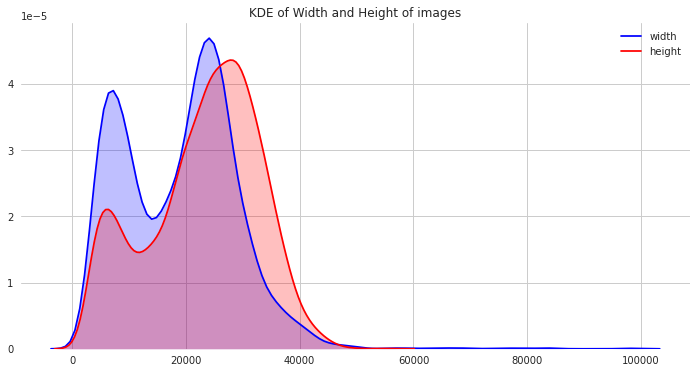

In [ ]:
plt.figure(figsize=(12,6))
p1=sns.kdeplot(train['width'], shade=True, color="b").set_title('KDE of Width and Height of images')
p2=sns.kdeplot(train['height'], shade=True, color="r")
plt.legend(labels=['width','height'])

# Stain Normalization (Macenko Method)

Using simplified stain normalization...
⚠️ 'image_id' column not found. Resetting train DataFrame...
Using sample: 002a4db09dad406c85505a00fb6f6144


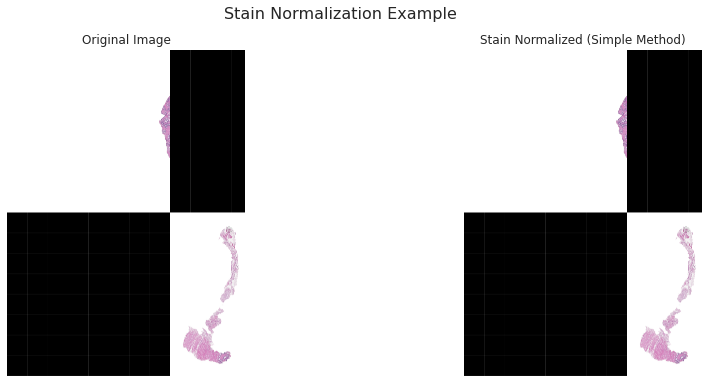

✅ Simple stain normalization completed successfully!


In [ ]:
# ==================== 1. STAIN NORMALIZATION (Robust Version) ====================

print("Using simplified stain normalization...")

def simple_stain_normalization(img):
    """Simple but effective stain normalization"""
    img = img.astype(np.float32)
    for i in range(3):
        channel = img[:, :, i]
        p2, p98 = np.percentile(channel, (2, 98))
        img[:, :, i] = np.clip((channel - p2) / (p98 - p2), 0, 1) * 255
    return img.astype(np.uint8)

# === Safe Sample Selection ===
if 'image_id' not in train.columns:
    print("⚠️ 'image_id' column not found. Resetting train DataFrame...")
    train = pd.read_csv(BASE_PATH / "train.csv")  # Reload

# Get a valid sample_id
sample_id = train['image_id'].iloc[5]
print(f"Using sample: {sample_id}")

# Read and normalize
slide_path = TRAIN_IMG_DIR / f"{sample_id}.tiff"
slide = openslide.OpenSlide(str(slide_path))
orig = np.array(slide.read_region((0, 0), 1, slide.level_dimensions[1]))[:, :, :3]
slide.close()

norm = simple_stain_normalization(orig)

# Plot
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(norm)
plt.title("Stain Normalized (Simple Method)")
plt.axis('off')
plt.suptitle("Stain Normalization Example", fontsize=16)
plt.show()

print("✅ Simple stain normalization completed successfully!")

# Feature Engineering (Haralick + Color Histograms)

In [ ]:
# ==================== 2. FEATURE ENGINEERING (Fixed) ====================
from skimage.feature import greycomatrix, greycoprops   # Use 'grey' for Kaggle
import cv2

def extract_tile_features(tile):
    """Extract Haralick texture + Color histogram features"""
    # Convert to grayscale and resize
    gray = cv2.cvtColor(tile, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (128, 128))

    # Compute GLCM (Grey Level Co-occurrence Matrix)
    glcm = greycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    haralick = {
        'contrast': greycoprops(glcm, 'contrast').mean(),
        'dissimilarity': greycoprops(glcm, 'dissimilarity').mean(),
        'homogeneity': greycoprops(glcm, 'homogeneity').mean(),
        'energy': greycoprops(glcm, 'energy').mean(),
        'correlation': greycoprops(glcm, 'correlation').mean(),
        'ASM': greycoprops(glcm, 'ASM').mean(),
    }

    # Color Histogram
    hist = []
    for channel in range(3):
        hist.extend(cv2.calcHist([tile], [channel], None, [8], [0, 256]).flatten())

    return {**haralick, 'color_hist': hist}


def extract_features_from_slide(image_id, n_tiles=12, tile_size=256):
    """Extract features from multiple tiles of one slide"""
    try:
        slide = openslide.OpenSlide(str(TRAIN_IMG_DIR / f"{image_id}.tiff"))
        level = slide.get_best_level_for_downsample(32)
        features = []

        for _ in range(n_tiles):
            x = np.random.randint(0, slide.level_dimensions[level][0] - tile_size)
            y = np.random.randint(0, slide.level_dimensions[level][1] - tile_size)

            tile = np.array(slide.read_region((x*32, y*32), level, (tile_size, tile_size)))[:, :, :3]

            feat = extract_tile_features(tile)
            feat['image_id'] = image_id
            feat['isup_grade'] = int(train.loc[train['image_id'] == image_id, 'isup_grade'].values[0])
            features.append(feat)

        slide.close()
        return pd.DataFrame(features)

    except Exception as e:
        print(f"Error processing {image_id}: {e}")
        return pd.DataFrame()


# === Run on Sample ===
print("Extracting Haralick + Color features from sample slides...")
sample_ids = train['image_id'].sample(50, random_state=42)  # Reduced for speed

sample_features_list = []
for i, img_id in enumerate(sample_ids):
    if i % 10 == 0:
        print(f"  Processed {i}/{len(sample_ids)} slides...")
    df = extract_features_from_slide(img_id, n_tiles=12)
    if not df.empty:
        sample_features_list.append(df)

sample_features = pd.concat(sample_features_list, ignore_index=True)

print(f"✅ Successfully extracted features: {sample_features.shape}")
sample_features.head()

Extracting Haralick + Color features from sample slides...
  Processed 0/50 slides...
  Processed 10/50 slides...
Error processing 73ca95633a46136d909f5ad45c7ddda1: low >= high
  Processed 20/50 slides...
  Processed 30/50 slides...
Error processing 30714dc10ad30cb8cda2ed487ebd4934: low >= high
  Processed 40/50 slides...
Error processing 095fc465913010fb51c3499000813454: low >= high
Error processing 158754df49e00760f8e4659a05e7cc0c: low >= high
✅ Successfully extracted features: (552, 9)


,contrast,dissimilarity,homogeneity,energy,correlation,ASM,color_hist,image_id,isup_grade
0,0.000000,0.000000,1.00000,1.00000,1.000000,1.000000,"[65536.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6...",e8baa3bb9dcfb9cef5ca599d62bb8046,4
1,0.000000,0.000000,1.00000,1.00000,1.000000,1.000000,"[65536.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6...",e8baa3bb9dcfb9cef5ca599d62bb8046,4
2,0.000000,0.000000,1.00000,1.00000,1.000000,1.000000,"[65536.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6...",e8baa3bb9dcfb9cef5ca599d62bb8046,4
3,0.000000,0.000000,1.00000,1.00000,1.000000,1.000000,"[65536.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6...",e8baa3bb9dcfb9cef5ca599d62bb8046,4
4,192.005906,1.505906,0.98819,0.70115,0.993984,0.491617,"[29440.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 36096....",e8baa3bb9dcfb9cef5ca599d62bb8046,4


# Dimensionality Reduction (UMAP on Tile Embeddings)

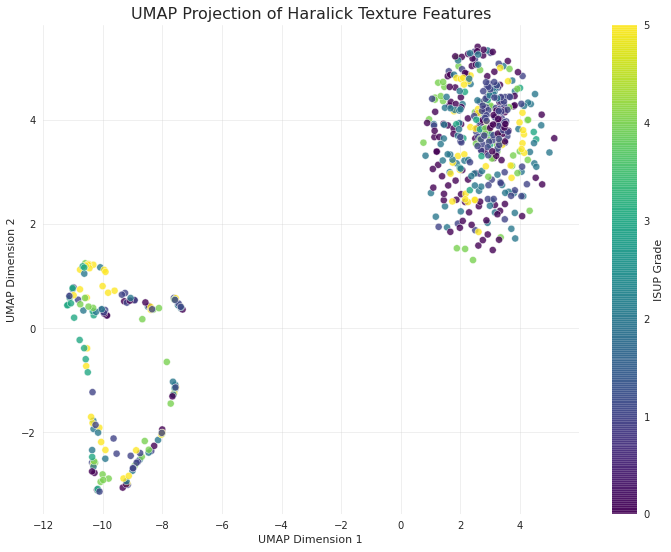

In [ ]:
# ==================== 3. UMAP DIMENSIONALITY REDUCTION ====================
!pip install -q umap-learn

import umap
from sklearn.preprocessing import StandardScaler

# Select numeric features
feature_cols = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
X = sample_features[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(12, 9))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=sample_features['isup_grade'].astype(int),
    cmap='viridis', s=50, alpha=0.8, edgecolors='w', linewidth=0.5
)
plt.colorbar(scatter, label='ISUP Grade')
plt.title('UMAP Projection of Haralick Texture Features', fontsize=16)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()